# Taller Práctico 3 — Detección de Trayectoria de Asteroides
### CPU (secuencial) vs GPU (CUDA con Numba)


In [ ]:
# Instalar dependencias necesarias en Colab
!pip install numba opencv-python-headless matplotlib numpy -q


In [ ]:
# ════════════════════════════════════════════════════════════
#  DIAGNÓSTICO — corre esto primero si no detecta
#  Te dice cuánto brilla el asteroide en cada frame
# ════════════════════════════════════════════════════════════
def diagnosticar_video(video_path, umbral=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        frames.append(gray)
    cap.release()

    if not frames:
        print("ERROR: no se pudieron leer frames del video")
        return

    frames_arr = np.array(frames)
    fondo = np.median(frames_arr, axis=0)

    print(f"{'Frame':>6}  {'Cambio máximo':>14}  {'Píxeles > umbral':>16}")
    print("-" * 42)
    for t, f in enumerate(frames):
        cambio = np.abs(f - fondo)
        max_cambio = cambio.max()
        pixeles_activos = (cambio > umbral).sum()
        marca = " ← ¡ASTEROIDE!" if pixeles_activos >= MIN_PIXELS else ""
        print(f"{t:>6}  {max_cambio:>14.1f}  {pixeles_activos:>16}{marca}")

# Descomenta para ejecutar:
diagnosticar_video("/content/v1.mp4")


 Frame   Cambio máximo  Píxeles > umbral
------------------------------------------
     0            22.0              5459 ← ¡ASTEROIDE!
     1            18.0              1324 ← ¡ASTEROIDE!
     2            47.0              1035 ← ¡ASTEROIDE!
     3            55.5               926 ← ¡ASTEROIDE!
     4            42.0               923 ← ¡ASTEROIDE!
     5            45.0               904 ← ¡ASTEROIDE!
     6            54.0               914 ← ¡ASTEROIDE!
     7            49.0               906 ← ¡ASTEROIDE!
     8            56.5               910 ← ¡ASTEROIDE!
     9            52.0               889 ← ¡ASTEROIDE!
    10            56.0               897 ← ¡ASTEROIDE!
    11            49.0               888 ← ¡ASTEROIDE!
    12            60.0              1327 ← ¡ASTEROIDE!
    13            56.0               963 ← ¡ASTEROIDE!
    14            49.0               841 ← ¡ASTEROIDE!
    15            56.0               795 ← ¡ASTEROIDE!
    16            52.0              

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab.patches import cv2_imshow

# ──────────────────────────────────────────────
# Parámetros comunes  (ajusta si no detecta)
# ──────────────────────────────────────────────
THRESHOLD   = 20   # umbral de brillo para considerar 'cambio'
KERNEL_SIZE = 3    # tamaño del kernel morfológico / blur
MIN_PIXELS  = 5    # mínimo de píxeles activos para confirmar detección

def plot_trajectory(positions, title="Trayectoria del Asteroide"):
    """Grafica la trayectoria detectada."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor("black")
    fig.patch.set_facecolor("black")

    if positions:
        xs = [p[0] for p in positions]
        ys = [p[1] for p in positions]
        ax.scatter(xs, ys, c=range(len(xs)), cmap="plasma", s=18, zorder=3)
        ax.plot(xs, ys, color="cyan", linewidth=1, alpha=0.6, zorder=2)
        ax.set_title(title, color="white", fontsize=13)
    else:
        ax.set_title("No se detectó asteroide — fondo estático", color="gray", fontsize=12)

    np.random.seed(42)
    sx = np.random.randint(0, 640, 200)
    sy = np.random.randint(0, 480, 200)
    ax.scatter(sx, sy, c="white", s=1, alpha=0.4, zorder=1)

    ax.set_xlabel("X (px)", color="white")
    ax.set_ylabel("Y (px)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("gray")
    plt.tight_layout()
    plt.show()


---
## 1. Versión CPU (Secuencial)
Pipeline: **Grayscale → Median Background → Sustracción → Umbralización → Erosión → Dilatación → Centroide**


  PROCESAMIENTO CPU
  Tiempo CPU  : 2.997 s
  Veredicto   :   EXISTE ASTEROIDE  (55 frames detectados)


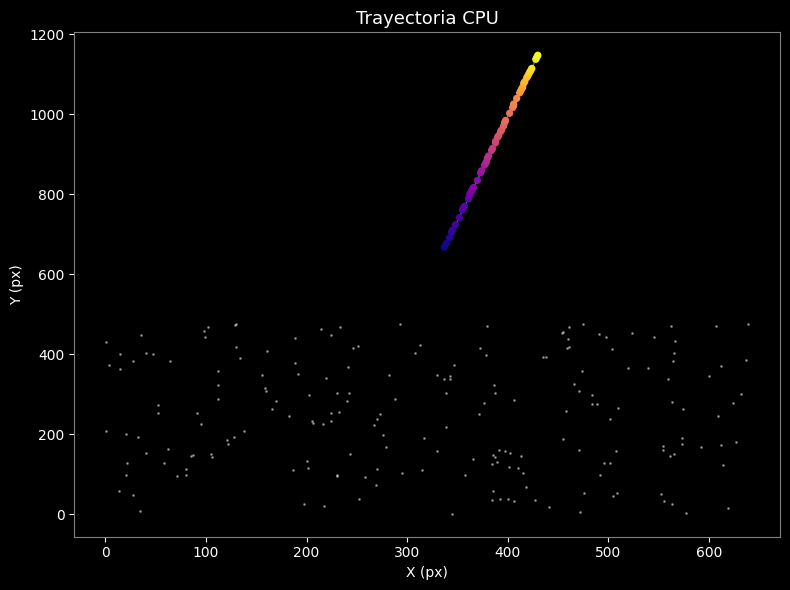

In [ ]:
# ════════════════════════════════════════════════════════════
#  ALGORITMO CPU — SECUENCIAL  (Median Background Subtraction)
# ════════════════════════════════════════════════════════════

def process_video_cpu(video_path: str):
    """
    Detecta un asteroide usando sustracción de fondo (mediana).
    Retorna:
        detected  (bool)         — ¿se encontró asteroide?
        positions (list[tuple])  — lista de centroides (x, y) por frame
        elapsed   (float)        — tiempo de cómputo en segundos
    """
    t0 = time.perf_counter()  # ← FIX: medir desde el inicio

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"No se pudo abrir: {video_path}")

    # ── Paso 1: cargar todos los frames en escala de grises ──
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        frames.append(gray)
    cap.release()

    if not frames:
        return False, [], 0.0

    frames_arr = np.array(frames)          # shape: (N, H, W)

    # ── Paso 2: imagen de fondo = mediana píxel a píxel ─────
    # El asteroide solo aparece en unos pocos frames,
    # la mediana lo elimina y conserva el fondo estático.
    I_fondo = np.median(frames_arr, axis=0)

    # ── Paso 3: detectar asteroide en cada frame ─────────────
    kernel_morph = np.ones((KERNEL_SIZE, KERNEL_SIZE), np.uint8)
    positions = []

    for t, frame in enumerate(frames):
        # Sustracción de fondo
        I_cambio = np.abs(frame - I_fondo)

        # Umbralización binaria
        thresh = (I_cambio > THRESHOLD).astype(np.uint8) * 255

        # Erosión: elimina ruido de píxeles aislados
        eroded  = cv2.erode(thresh,  kernel_morph, iterations=1)

        # Dilatación: restaura el tamaño del objeto real
        dilated = cv2.dilate(eroded, kernel_morph, iterations=1)

        # Centroide: promedio de los píxeles activos
        white_pixels = np.argwhere(dilated == 255)
        if len(white_pixels) >= MIN_PIXELS:
            cy, cx = white_pixels.mean(axis=0)
            positions.append((int(cx), int(cy)))

    elapsed = time.perf_counter() - t0
    detected = len(positions) > 0
    return detected, positions, elapsed


# ── Ejecutar CPU ─────────────────────────────────────────────
VIDEO_PATH = "/content/v1.mp4"   # 🔁 Cambia al path de tu video

print("=" * 50)
print("  PROCESAMIENTO CPU")
print("=" * 50)

detected_cpu, positions_cpu, time_cpu = process_video_cpu(VIDEO_PATH)

print(f"  Tiempo CPU  : {time_cpu:.3f} s")
if detected_cpu:
    print(f"  Veredicto   :   EXISTE ASTEROIDE  ({len(positions_cpu)} frames detectados)")
else:
    print(f"  Veredicto   :   NO EXISTE ASTEROIDE")

plot_trajectory(positions_cpu, title="Trayectoria CPU")


---
## 2. Versión GPU (CUDA con Numba)
Los kernels CUDA implementan: **Blur 3×3 → Median Background → Sustracción → Umbralización → Erosión → Dilatación**.
El cálculo del centroide se hace en CPU sobre la máscara resultante.


  PROCESAMIENTO GPU (CUDA)
  Tiempo GPU  : 2.653 s
  Veredicto   : ✅  EXISTE ASTEROIDE  (38 frames detectados)


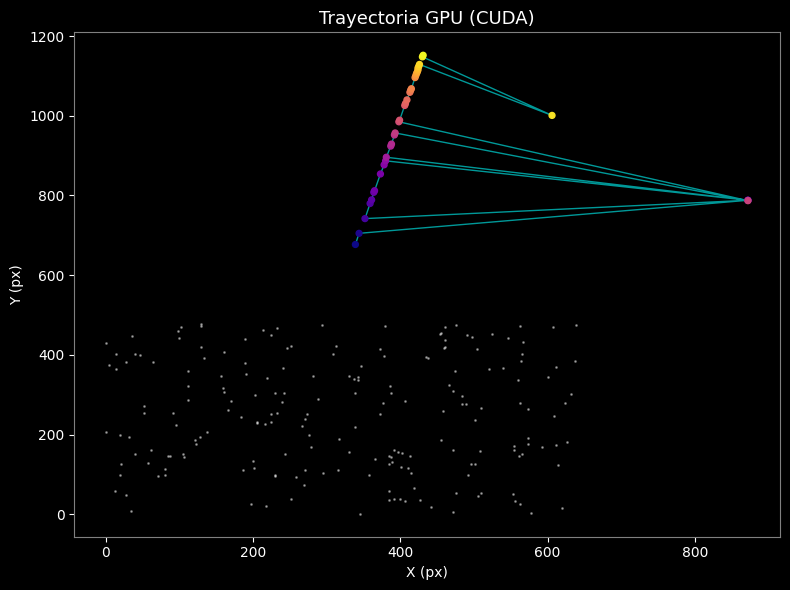

In [ ]:
# ════════════════════════════════════════════════════════════
#  ALGORITMO GPU — CUDA con Numba  (Median Background Subtraction)
# ════════════════════════════════════════════════════════════
from numba import cuda
import math

# ── Kernel 1: Blur 3×3 (media espacial) ─────────────────────
@cuda.jit
def kernel_blur(src, dst, rows, cols):
    x, y = cuda.grid(2)
    if x < rows and y < cols:
        total = 0.0
        count = 0
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                nx, ny = x + dy, y + dx
                if 0 <= nx < rows and 0 <= ny < cols:
                    total += src[nx, ny]
                    count += 1
        dst[x, y] = total / count


# ── Kernel 2: Mediana píxel a píxel (insertion sort) ────────
# Calcula la imagen de fondo: mediana de todos los frames por píxel.
# NOTA: max_frames debe coincidir con el número real de frames del video.
@cuda.jit
def kernel_median_stack(frames_d, background_d, n_frames, rows, cols):
    x, y = cuda.grid(2)
    if x < rows and y < cols:
        # Buffer local para valores del píxel (x,y) en todos los frames
        vals = cuda.local.array(512, dtype=cuda.float32)  # max 512 frames
        for t in range(n_frames):
            vals[t] = frames_d[t, x, y]
        # Insertion sort
        for i in range(1, n_frames):
            key = vals[i]
            j = i - 1
            while j >= 0 and vals[j] > key:
                vals[j + 1] = vals[j]
                j -= 1
            vals[j + 1] = key
        # Mediana
        mid = n_frames // 2
        if n_frames % 2 == 0:
            background_d[x, y] = (vals[mid - 1] + vals[mid]) / 2.0
        else:
            background_d[x, y] = vals[mid]


# ── Kernel 3: Sustracción de fondo + umbralización ──────────
# FIX: nombre corregido (antes se llamaba kernel_subtract_and_thresh
#      pero estaba definido como kernel_subtract → NameError)
@cuda.jit
def kernel_subtract(frame_d, background_d, out_d, threshold):
    x, y = cuda.grid(2)
    if x < frame_d.shape[0] and y < frame_d.shape[1]:
        diff = abs(frame_d[x, y] - background_d[x, y])
        out_d[x, y] = 255.0 if diff >= threshold else 0.0


# ── Kernel 4: Erosión 3×3 ───────────────────────────────────
@cuda.jit
def kernel_erode(src, dst, rows, cols):
    x, y = cuda.grid(2)
    if x < rows and y < cols:
        val = 255.0
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                nx, ny = x + dy, y + dx
                if 0 <= nx < rows and 0 <= ny < cols:
                    if src[nx, ny] == 0.0:
                        val = 0.0
                        break
            if val == 0.0:
                break
        dst[x, y] = val


# ── Kernel 5: Dilatación 3×3 ────────────────────────────────
@cuda.jit
def kernel_dilate(src, dst, rows, cols):
    x, y = cuda.grid(2)
    if x < rows and y < cols:
        val = 0.0
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                nx, ny = x + dy, y + dx
                if 0 <= nx < rows and 0 <= ny < cols:
                    if src[nx, ny] == 255.0:
                        val = 255.0
                        break
            if val == 255.0:
                break
        dst[x, y] = val


# ── Configuración de grilla CUDA ────────────────────────────
THREADS = (16, 16)

def make_grid(rows, cols):
    return (math.ceil(rows / THREADS[0]), math.ceil(cols / THREADS[1]))


# ── Pipeline GPU completo ────────────────────────────────────
def process_video_gpu(video_path: str):
    """
    Detecta un asteroide con sustracción de fondo (mediana) en CUDA.
    Retorna:
        detected  (bool)
        positions (list[tuple])
        elapsed   (float)
    """
    t0 = time.perf_counter()  # ← FIX: medir desde el inicio (incluyendo median)

    # ── Paso 1: leer todos los frames en CPU ─────────────────
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"No se pudo abrir: {video_path}")

    frames_cpu = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        frames_cpu.append(gray)
    cap.release()

    if not frames_cpu:
        return False, [], 0.0

    rows, cols = frames_cpu[0].shape
    n_frames   = len(frames_cpu)
    grid       = make_grid(rows, cols)

    # ── Paso 2: subir todos los frames a la GPU ───────────────
    frames_arr = np.array(frames_cpu, dtype=np.float32)   # (N, H, W)
    frames_d   = cuda.to_device(frames_arr)

    # ── Paso 3: calcular fondo (mediana) en GPU ───────────────
    background_d = cuda.device_array((rows, cols), dtype=np.float32)
    kernel_median_stack[grid, THREADS](frames_d, background_d, n_frames, rows, cols)
    cuda.synchronize()

    # ── Paso 4: detectar asteroide frame a frame ──────────────
    # FIX: todos los buffers intermedios son float32 (consistente con kernel_subtract)
    blurred_d  = cuda.device_array((rows, cols), dtype=np.float32)
    diff_d     = cuda.device_array((rows, cols), dtype=np.float32)
    eroded_d   = cuda.device_array((rows, cols), dtype=np.float32)
    dilated_d  = cuda.device_array((rows, cols), dtype=np.float32)

    positions = []

    for t in range(n_frames):
        curr_d = cuda.to_device(frames_cpu[t])

        # Blur espacial
        kernel_blur[grid, THREADS](curr_d, blurred_d, rows, cols)
        cuda.synchronize()

        # Sustracción de fondo + umbralización
        # FIX: nombre correcto del kernel
        kernel_subtract[grid, THREADS](blurred_d, background_d, diff_d, THRESHOLD)
        cuda.synchronize()

        # Erosión
        kernel_erode[grid, THREADS](diff_d, eroded_d, rows, cols)
        cuda.synchronize()

        # Dilatación
        kernel_dilate[grid, THREADS](eroded_d, dilated_d, rows, cols)
        cuda.synchronize()

        # Centroide en CPU
        mask_cpu = dilated_d.copy_to_host()
        white_pixels = np.argwhere(mask_cpu == 255.0)
        if len(white_pixels) >= MIN_PIXELS:
            cy, cx = white_pixels.mean(axis=0)
            positions.append((int(cx), int(cy)))

    elapsed  = time.perf_counter() - t0
    detected = len(positions) > 0
    return detected, positions, elapsed


# ── Ejecutar GPU ─────────────────────────────────────────────
print("=" * 50)
print("  PROCESAMIENTO GPU (CUDA)")
print("=" * 50)

detected_gpu, positions_gpu, time_gpu = process_video_gpu(VIDEO_PATH)

print(f"  Tiempo GPU  : {time_gpu:.3f} s")
if detected_gpu:
    print(f"  Veredicto   : ✅  EXISTE ASTEROIDE  ({len(positions_gpu)} frames detectados)")
else:
    print(f"  Veredicto   : ❌  NO EXISTE ASTEROIDE")

plot_trajectory(positions_gpu, title="Trayectoria GPU (CUDA)")


---
## 3. Comparativa de Rendimiento CPU vs GPU


╔══════════════════════════════════════════╗
║       COMPARATIVA CPU  vs  GPU           ║
╠══════════════════════════════════════════╣
║  Tiempo CPU          :    2.997 s         ║
║  Tiempo GPU (CUDA)   :    2.653 s         ║
║  Speedup GPU/CPU     :     1.13 x         ║
╠══════════════════════════════════════════╣
║  Asteroide (CPU)     :       SÍ            ║
║  Asteroide (GPU)     :       SÍ            ║
╚══════════════════════════════════════════╝


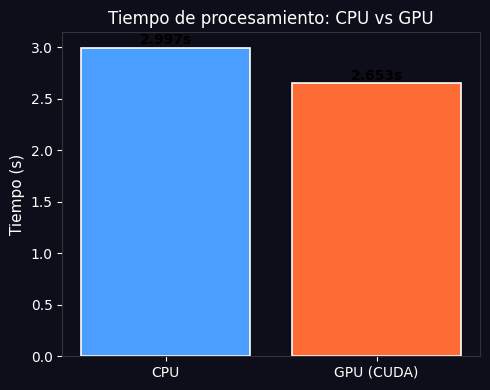

In [ ]:
# ════════════════════════════════════════════════════════════
#  COMPARATIVA DE RENDIMIENTO
# ════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════╗")
print("║       COMPARATIVA CPU  vs  GPU           ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Tiempo CPU          : {time_cpu:>8.3f} s         ║")
print(f"║  Tiempo GPU (CUDA)   : {time_gpu:>8.3f} s         ║")
if time_gpu > 0:
    speedup = time_cpu / time_gpu
    print(f"║  Speedup GPU/CPU     : {speedup:>8.2f} x         ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Asteroide (CPU)     : {'SÍ' if detected_cpu else 'NO':>8}            ║")
print(f"║  Asteroide (GPU)     : {'SÍ' if detected_gpu else 'NO':>8}            ║")
print("╚══════════════════════════════════════════╝")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["CPU", "GPU (CUDA)"], [time_cpu, time_gpu],
              color=["#4a9eff", "#ff6b35"], edgecolor="white", linewidth=1.2)
ax.set_ylabel("Tiempo (s)", fontsize=11)
ax.set_title("Tiempo de procesamiento: CPU vs GPU", fontsize=12)
for bar, val in zip(bars, [time_cpu, time_gpu]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_facecolor("#0e0e1a")
fig.patch.set_facecolor("#0e0e1a")
ax.tick_params(colors="white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")
plt.tight_layout()
plt.show()
